#### Data Preparation: Before building a model, you must handle the "messy" parts of the Titanic data. You will need pandas, sklearn.tree, sklearn.ensemble, and sklearn.metrics.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('usethistitanic.csv')

df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


#### Start with some preliminary data exploration (at least 4 graphs needed here!). How will you handle the missing values in the Age column, and how will you convert the categorical Sex column into a numerical format that a Decision Tree can understand?

In [3]:
df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

<Axes: >

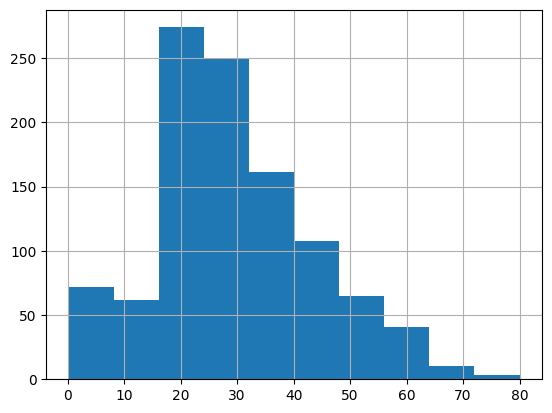

In [4]:
df['age'].hist()

<Axes: >

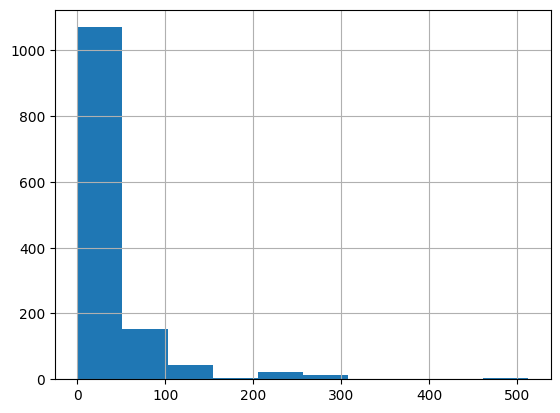

In [5]:
df['fare'].hist()

In [6]:
df['sex'] = df['sex'].map({'male': 1, 'female': 0}) #.map takes a dictionary where the keys correspond to the values in your dataset and the dictionary values are substituted in
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",0,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",1,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",0,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",1,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",0,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


<Axes: >

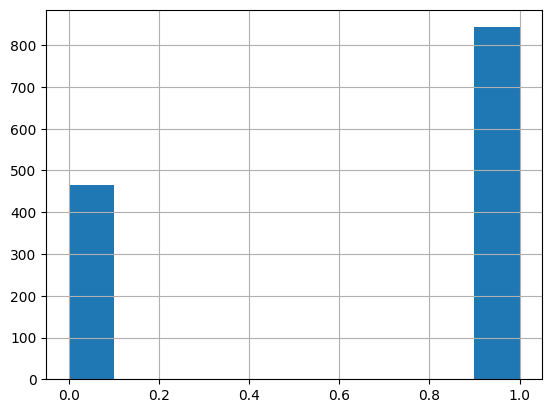

In [7]:
df['sex'].hist()

In [8]:
df['age'].fillna(df['age'].median(), inplace = True)

In [9]:
df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age             0
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

<Axes: >

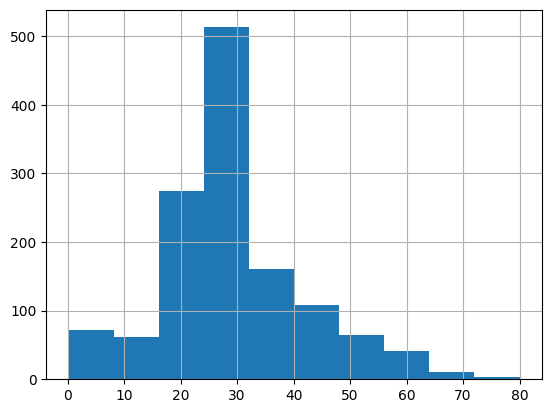

In [10]:
df['age'].hist()

#### The Initial Split: Split your data into a training set and a testing set (typically 80/20). Why is it important to use a random_state parameter when performing this split?

In [11]:
from sklearn.model_selection import train_test_split
X = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
y = df['survived']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=0)

print('Xtrain shape:', Xtrain.shape)
print('Xtest shape:', Xtest.shape)
print('ytrain shape:', ytrain.shape)
print('ytest shape:', ytest.shape)

Xtrain shape: (1047, 6)
Xtest shape: (262, 6)
ytrain shape: (1047,)
ytest shape: (262,)


#### Training the Tree: Look up the parameters of the DecisionTreeClassifier. Initialize a DecisionTreeClassifier and fit it to your training data. At this stage, do not set any limits on the depth of the tree. Once trained, calculate the accuracy on the training set vs. the test set. If the training accuracy is 100% but the test accuracy is 70%, what has happened to your model?

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=0)
dt.fit(Xtrain, ytrain)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [13]:
train_accuracy = dt.score(Xtrain, ytrain)
test_accuracy = dt.score(Xtest, ytest)

print('Training accuracy:', train_accuracy)
print('Test accuracy:', test_accuracy)

Training accuracy: 0.9684813753581661
Test accuracy: 0.7709923664122137


The test accuracy is 77% while the training accuracy was 96% this likely means the model is overfitted to the training data.

#### Visualizing the Logic: Use plot_tree from Scikit-Learn to look at the first three levels of your tree. Which feature did the model choose for the very first "split" at the top (the root node)? Based on Titanic history, does this split make logical sense to you?

[Text(0.5267857142857143, 0.9, 'sex <= 0.5\ngini = 0.472\nsamples = 1047\nvalue = [647, 400]\nclass = Died'),
 Text(0.2857142857142857, 0.7, 'pclass <= 2.5\ngini = 0.402\nsamples = 384\nvalue = [107, 277]\nclass = Survived'),
 Text(0.40625, 0.8, 'True  '),
 Text(0.14285714285714285, 0.5, 'fare <= 31.681\ngini = 0.134\nsamples = 208\nvalue = [15.0, 193.0]\nclass = Survived'),
 Text(0.07142857142857142, 0.3, 'fare <= 31.34\ngini = 0.233\nsamples = 89\nvalue = [12, 77]\nclass = Survived'),
 Text(0.03571428571428571, 0.1, '\n  (...)  \n'),
 Text(0.10714285714285714, 0.1, '\n  (...)  \n'),
 Text(0.21428571428571427, 0.3, 'age <= 2.5\ngini = 0.049\nsamples = 119\nvalue = [3, 116]\nclass = Survived'),
 Text(0.17857142857142858, 0.1, '\n  (...)  \n'),
 Text(0.25, 0.1, '\n  (...)  \n'),
 Text(0.42857142857142855, 0.5, 'fare <= 23.35\ngini = 0.499\nsamples = 176\nvalue = [92, 84]\nclass = Died'),
 Text(0.35714285714285715, 0.3, 'fare <= 7.744\ngini = 0.494\nsamples = 148\nvalue = [66, 82]\nclass

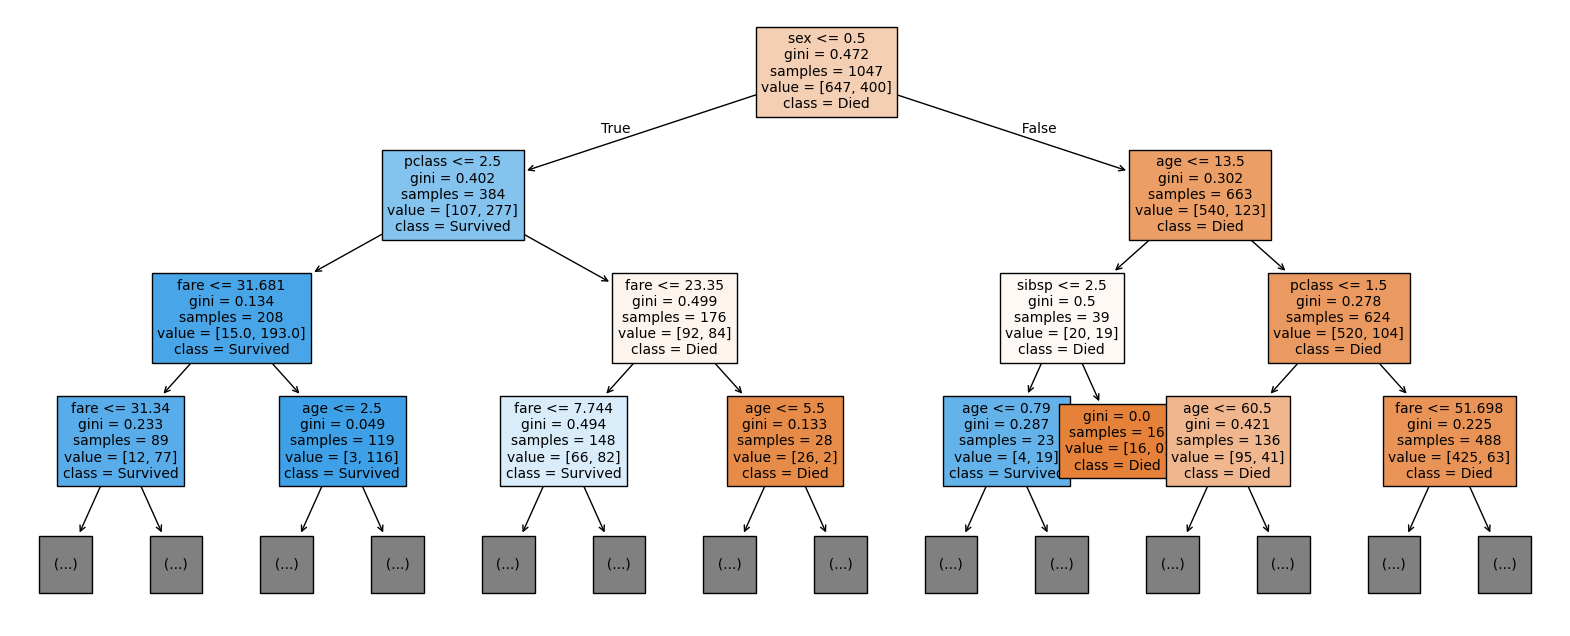

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, fontsize=10)


the first split it made was by gender as seen in the top middle box. this makes sense to me.

#### Pruning for Health: Re-train the model, but this time set max_depth=3. Compare the test accuracy of this "shorter" tree to your previous deep tree. Why does limiting the tree's growth often improve performance on the test set?

In [15]:
dt = DecisionTreeClassifier(max_depth=3,random_state=1)
dt.fit(Xtrain, ytrain)

train_accuracy = dt.score(Xtrain, ytrain)
test_accuracy = dt.score(Xtest, ytest)

print('Training accuracy:', train_accuracy)
print('Test accuracy:', test_accuracy)

Training accuracy: 0.8175740210124164
Test accuracy: 0.8129770992366412


the training accuracy went down and the test accuracy went up because the tree is shorter. this means the tree is less fit to the training data and works better for new data. however, this means that the model no longer scores super high on the trainging data but is now more consistent.

#### Growing the Forest: Now, initialize a RandomForestClassifier with 100 trees (n_estimators=100). Train it on the same data. In your own words, how is the way this forest makes a prediction different from the single tree you built in Question 3?

In [16]:
from sklearn.ensemble import RandomForestClassifier

dt3 = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=1)

X3 = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
y3 = df['survived']

Xtrain3, Xtest3, ytrain3, ytest3 = train_test_split(X3, y3, test_size=0.2, random_state=0)

print('Xtrain3 shape:', Xtrain3.shape)
print('Xtest3 shape:', Xtest3.shape)
print('ytrain3 shape:', ytrain3.shape)
print('ytest3 shape:', ytest3.shape)

Xtrain3 shape: (1047, 6)
Xtest3 shape: (262, 6)
ytrain3 shape: (1047,)
ytest3 shape: (262,)


In [17]:
dt3.fit(Xtrain3, ytrain3)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [18]:
train_accuracy3 = dt3.score(Xtrain3, ytrain3)
test_accuracy3 = dt3.score(Xtest3, ytest3)

print('Training accuracy:', train_accuracy3)
print('Test accuracy:', test_accuracy3)

Training accuracy: 0.8271251193887297
Test accuracy: 0.8129770992366412


This forest is different because it uses multiple trees that all have their own ways to decide who survived and who died instead of just using one.

#### Investigating Errors (Type I vs Type II): Generate a Confusion Matrix for your Random Forest predictions. How many passengers did the model predict would survive who actually died (False Positives), and how many did it predict would die who actually survived (False Negatives)?

In [19]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

ypredict3 = dt3.predict(Xtest3)

cm = confusion_matrix(ytest3, ypredict3)
print(cm)

[[151  11]
 [ 38  62]]


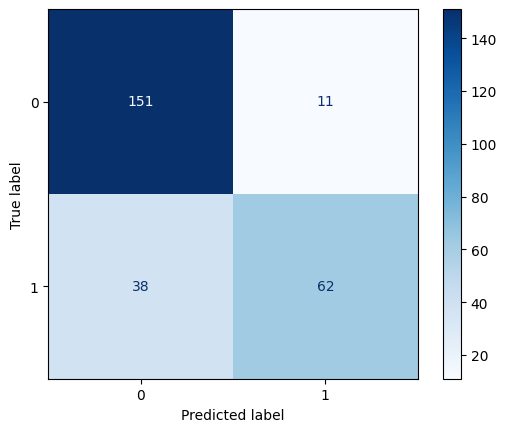

In [20]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

very good at predicting who died, slightly worse at predicting who survived.

predicited 11 would survive that actually died False Positive. predicted 38 would die that actually survived False Negative.  

#### The Tradeoff: Calculate the Precision and Recall. If you were a rescue coordinator and your goal was to "leave no one behind" (ensure every survivor is found), would you be more concerned with maximizing Precision or Recall?

In [21]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(ytest3, ypredict3)
recall = recall_score(ytest3, ypredict3)

print(f'precision: {precision}\nrecall: {recall}')

precision: 0.8493150684931506
recall: 0.62


as a rescuer you want to improve your recall score, thus lowering type II errors because you would rather bring home some dead people you think are alive as long as you bring home everyone who is actually alive.

#### Measuring Discrimination (ROC AUC): Plot the ROC Curve and calculate the AUC score for your Random Forest. If your AUC is 0.85, what does that tell you about the model’s ability to distinguish between a survivor and a victim compared to a random coin flip?

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

fpr, tpr, thresholds = roc_curve(ytest3, ypredict3)
score = roc_auc_score(ytest3, ypredict3)
print(fpr, tpr)

[0.         0.06790123 1.        ] [0.   0.62 1.  ]


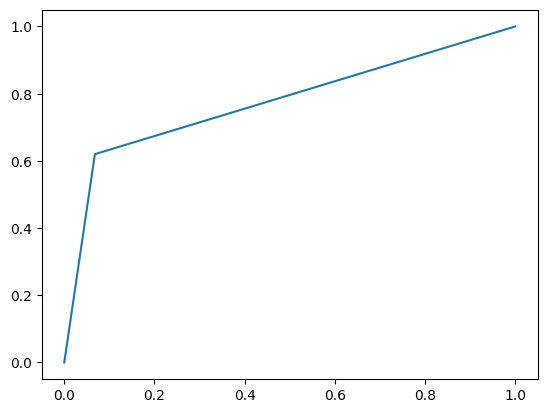

In [ ]:
plt.plot(fpr,tpr)

In [24]:
print(score)

0.7760493827160495


the area under the curve is 0.77. this means that the model preforms better than simply flipping a coin which would yield a score of 0.5, but still the model is not as good as we would like it to be

In [28]:
print(dt3.feature_importances_)
print(X3.columns)

[0.15741295 0.56036586 0.05407892 0.04339037 0.03186941 0.15288249]
Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare'], dtype='object')


<BarContainer object of 6 artists>

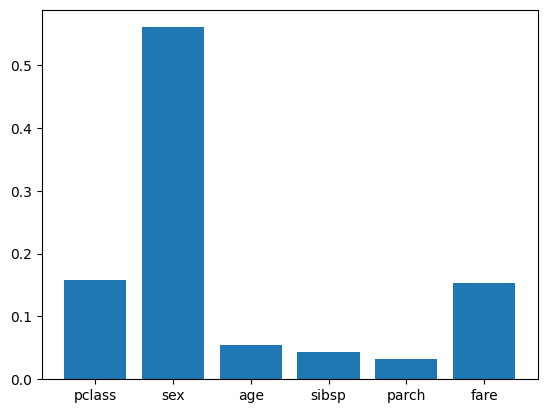

In [29]:
plt.bar(X3.columns, dt3.feature_importances_)

the top 3 most important features for the model were sex, pclass, and fare. these make since considering the policy of women and children first, and the different classes of rooms were located in different parts of the ship. fare makes since because it is directly related to class. maybe it shouldn't have been included because they essentially tell us the same thing.